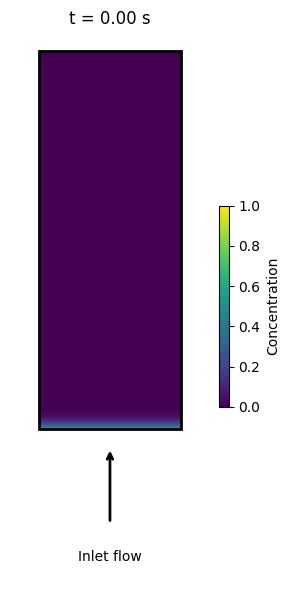

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle

# -----------------------------
# 1. "Physics": build fake C(z,t)
# -----------------------------
L = 1.0           # column height [m]
Nz = 200          # vertical grid
Nt = 200          # time steps
u = 0.3           # front velocity [m/s]
t_end = 3.0       # final time [s]

z = np.linspace(0, L, Nz)
t = np.linspace(0, t_end, Nt)

# C(t,z): smooth front moving up
C = np.zeros((Nt, Nz))
for i, ti in enumerate(t):
    z_front = u * ti
    # smooth step (tanh) as a fake mass-transfer zone
    C[i, :] = 0.5 * (1 + np.tanh((z_front - z) / 0.02))
    # clip to keep it nice
    C[i, :] = np.clip(C[i, :], 0, 1)

# ---------------------------------
# 2. Turn 1D profile into a column
# ---------------------------------
# Visually, we make a narrow 2D image: height = z, width = a few pixels
column_width_px = 30
C2d_0 = np.tile(C[0, :][:, None], (1, column_width_px))  # (Nz, width)

fig, ax = plt.subplots(figsize=(3, 6))

# Plot column interior as an image
im = ax.imshow(
    C2d_0,
    origin="lower",
    extent=[0, 1, 0, L],   # x from 0–1 (fake width), y is column height
    aspect="auto",
    vmin=0, vmax=1,
    cmap="viridis"
)

# Draw a rectangle outline for the column wall
col_outline = Rectangle(
    (0, 0),      # bottom-left corner
    1,           # width
    L,           # height
    fill=False,
    linewidth=2,
    edgecolor="black"
)
ax.add_patch(col_outline)

# Flow arrow at the bottom
ax.annotate(
    "", xy=(0.5, -0.05 * L), xytext=(0.5, -0.25 * L),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)
ax.text(0.5, -0.32 * L, "Inlet flow", ha="center", va="top")

# Clean up axes so it looks like a physical object
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.4 * L, L * 1.05)
ax.axis("off")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Concentration")

title = ax.set_title("t = 0.00 s")

# -----------------------
# 3. Animation functions
# -----------------------
def init():
    im.set_array(C2d_0)
    title.set_text("t = 0.00 s")
    return im, title

def update(frame):
    C_profile = C[frame, :]                   # (Nz,)
    C2d = np.tile(C_profile[:, None], (1, column_width_px))  # (Nz, width)
    im.set_array(C2d)
    title.set_text(f"t = {t[frame]:.2f} s")
    return im, title

anim = FuncAnimation(
    fig,
    update,
    init_func=init,
    frames=Nt,
    interval=50,
    blit=True
)

plt.tight_layout()
plt.show()

# To save:
# anim.save("column_concentration.mp4", writer="ffmpeg", fps=20)
# or:
from matplotlib.animation import PillowWriter
anim.save("column_concentration.gif", writer=PillowWriter(fps=20))


In [1]:
from pyEQL import Solution

c:\Users\janlc\miniconda3\envs\AdsColumn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sol = Solution({"Li+": "50mol/m^3"})

In [4]:
print(sol)

Volume: 0.764 l
Temperature: 298.150 K
Pressure: 1.000 atm
pH: 6.9
pE: 8.5
Solvent: H2O(aq)
Components: KeysView({'H2O(aq)': np.float64(55.34457595832858), 'Li[+1]': np.float64(50.27615780574777), 'OH[-1]': 1.0000000000000001e-07, 'H[+1]': 1e-07})
